In [1]:
# ===== 请将您的实验日志全文粘贴到下面的三引号字符串中 =====
data = """
------------------------------ Experiment: KAN, Standard, (Adam+LBFGS),  ------------------------------
[0.9977035692427868, 0.8294525053022476, 1.015168101322064, 0.9728210773517707, 0.8208185019668012, 0.8312073151861858, 0.8359697362318121, 0.7981420477608323, 0.812356582914149, 0.8067572089486532]
Error u of KAN, Standard, (Adam+LBFGS), : 8.720397e-01
[0.609346311758054, 0.48707592686090406, 0.604281704034167, 0.6004245728843488, 0.479688190278046, 0.4886710271731443, 0.4918269239222557, 0.4627622279150348, 0.4747483931518159, 0.4713304540336575]
MAE of KAN, Standard, (Adam+LBFGS), : 5.170156e-01
[0.49663959262238433, 0.34325852637212395, 0.5141788551656278, 0.4721763496021031, 0.3361495713061406, 0.34471247491715873, 0.34867386672921896, 0.31783276720590975, 0.3292544819362116, 0.3247311846381375]
MSE of KAN, Standard, (Adam+LBFGS), : 3.827608e-01


------------------------------ Experiment: KAN, Residual, (Adam+LBFGS),  ------------------------------
[0.8444727691111951, 0.7996785905084993, 0.8055804943696316, 0.8457798459493129, 0.8259194419966556, 0.8383249734853289, 0.8433893997641952, 0.8158764022934326, 0.8323745550661841, 0.8227515542407116]
Error u of KAN, Residual, (Adam+LBFGS), : 8.274148e-01
[0.49789326589776484, 0.46389732011224094, 0.4665366147290195, 0.49955446975630774, 0.48327594614926356, 0.49331925510282093, 0.49691319118010685, 0.476210870640857, 0.4901575598974044, 0.48118177742546187]
MAE of KAN, Residual, (Adam+LBFGS), : 4.848940e-01
[0.35580298473888344, 0.3190576963304683, 0.32378458696800905, 0.3569052624420538, 0.3403405263046214, 0.35064132193950426, 0.35489065504580186, 0.33211388391813634, 0.34568129377411405, 0.3377347203607908]
MSE of KAN, Residual, (Adam+LBFGS), : 3.416953e-01


------------------------------ Experiment: KAN, Failure, (Adam+LBFGS),  ------------------------------
[0.9783689251644553, 0.9535060636466816, 0.8313885413375356, 0.8193200690551241, 0.8663511969495089, 1.1120154838869392, 0.973218123889971, 1.2489206524819287, 0.928782140366001, 1.2041046371206956]
Error u of KAN, Failure, (Adam+LBFGS), : 9.915976e-01
[0.6017588984190002, 0.5577753226963343, 0.48826541901100307, 0.47870747371228606, 0.5158097239386922, 0.6303850341054082, 0.5815597259037366, 0.6331986927842905, 0.5674216761792269, 0.6846205772049028]
MAE of KAN, Failure, (Adam+LBFGS), : 5.739503e-01
[0.4775772029944257, 0.45361270046045676, 0.34486280498332267, 0.33492338592922377, 0.374477946596888, 0.6169641883591733, 0.4725618557297065, 0.7782300239309059, 0.4303937922269482, 0.7233804127641543]
MSE of KAN, Failure, (Adam+LBFGS), : 5.006984e-01


------------------------------ Experiment: KAN, Failure + Residual, (Adam+LBFGS),  ------------------------------
[0.80351201596371, 0.7904965264094307, 0.7969751596919413, 0.8429577074287105, 0.7645246434503008, 0.8985348844878296, 0.8237988583286233, 0.8187474669677935, 0.8337471501986441, 0.8209200949920187]
Error u of KAN, Failure + Residual, (Adam+LBFGS), : 8.194215e-01
[0.46769191942622207, 0.45712464419177706, 0.4617527272817897, 0.49676515267450067, 0.4388185128082664, 0.5418895706011565, 0.48373624902701484, 0.47761774192877754, 0.48946781732548067, 0.4804472012950405]
MAE of KAN, Failure + Residual, (Adam+LBFGS), : 4.795312e-01
[0.3221239668614476, 0.3117727968977496, 0.3169041000490903, 0.3545274435403671, 0.2916226586498231, 0.40281735425295867, 0.3385950920631739, 0.3344554105365032, 0.3468222985541663, 0.3362327871820011]
MSE of KAN, Failure + Residual, (Adam+LBFGS), : 3.355874e-01


"""

In [2]:
import re
import numpy as np


# ===== 解析代码 =====
def parse_error_u(text):
    """
    从日志文本中提取每个实验名称及其对应的 error u 列表（10个数字）
    """
    # 按实验块分割
    blocks = re.split(r'\-{30,} Experiment: ', text)
    experiments = {}
    for block in blocks:
        if not block.strip():
            continue
        lines = block.strip().split('\n')
        if not lines:
            continue
        # 第一行是实验名称（可能包含前导空格，但已经被strip去掉）
        exp_name = lines[0].strip()
        # 在后续行中找以 '[' 开头的行，取第一个这样的行作为 error u 列表
        for line in lines[1:]:
            line = line.strip()
            if line.startswith('['):
                # 提取所有浮点数
                nums = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if nums:
                    values = [float(x) for x in nums]
                    if len(values) == 10:   # 假设就是10个seed
                        experiments[exp_name] = values
                        break
    return experiments

def compute_stats(exp_dict):
    results = []
    for name, vals in exp_dict.items():
        mean = np.mean(vals)
        var = np.var(vals, ddof=1)   # 样本方差
        std = np.std(vals, ddof=1)
        results.append((name, vals, mean, var, std))
    results.sort(key=lambda x: x[2])  # 按均值升序
    return results

def print_results(results):
    print("\n========== 各实验 Error u 统计比较（按均值升序） ==========\n")
    print(f"{'实验名称':<45} {'均值':<12} {'样本方差':<14} {'标准差':<12} {'10个seed的error u'}")
    print("-" * 130)
    for name, vals, mean, var, std in results:
        vals_str = ", ".join([f"{v:.4f}" for v in vals])
        print(f"{name:<45} {mean:.6f}    {var:.6f}     {std:.6f}    [{vals_str}]")
    print("\n")

# 运行
if __name__ == "__main__":
    exp_dict = parse_error_u(data)
    if not exp_dict:
        print("未解析到任何实验数据，请检查文本格式。")
    else:
        results = compute_stats(exp_dict)
        print_results(results)


========== 各实验 Error u 统计比较（按均值升序） ==========

实验名称                                          均值           样本方差           标准差          10个seed的error u
----------------------------------------------------------------------------------------------------------------------------------
KAN, Failure + Residual, (Adam+LBFGS),  ------------------------------ 0.819421    0.001294     0.035974    [0.8035, 0.7905, 0.7970, 0.8430, 0.7645, 0.8985, 0.8238, 0.8187, 0.8337, 0.8209]
KAN, Residual, (Adam+LBFGS),  ------------------------------ 0.827415    0.000270     0.016432    [0.8445, 0.7997, 0.8056, 0.8458, 0.8259, 0.8383, 0.8434, 0.8159, 0.8324, 0.8228]
KAN, Standard, (Adam+LBFGS),  ------------------------------ 0.872040    0.007458     0.086361    [0.9977, 0.8295, 1.0152, 0.9728, 0.8208, 0.8312, 0.8360, 0.7981, 0.8124, 0.8068]
KAN, Failure, (Adam+LBFGS),  ------------------------------ 0.991598    0.022535     0.150118    [0.9784, 0.9535, 0.8314, 0.8193, 0.8664, 1.1120, 0.9732, 1.2489, 0.9288, 1

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_min_values(exp_dict, top_n=None, save_path=None):
    """
    绘制每个实验的10个seed中的最小值的柱状图（按最小值升序排列）
    
    参数:
        exp_dict: 解析后的实验字典
        top_n: 只显示最小值最小的前N个实验（None表示全部）
        save_path: 保存图片路径，如 'min_values.png'，为None则显示
    """
    # 计算每个实验的最小值
    min_vals = {name: np.min(vals) for name, vals in exp_dict.items()}
    # 按最小值升序排序
    sorted_items = sorted(min_vals.items(), key=lambda x: x[1])
    if top_n is not None:
        sorted_items = sorted_items[:top_n]
    
    names = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(names, values, color='skyblue', edgecolor='black')
    
    # 在柱顶标注数值
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel('Minimum Error u (among 10 seeds)', fontsize=12)
    ax.set_title('Comparison of Minimum Error u across Experiments', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

def plot_seed_trends(exp_dict, highlight_best=True, save_path=None):
    """
    绘制每个实验的10个seed值的折线图（x轴为seed编号1~10）
    
    参数:
        exp_dict: 解析后的实验字典
        highlight_best: 是否用特殊颜色突出显示均值最小的实验
        save_path: 保存图片路径
    """
    # 按均值排序，以便图例有序
    sorted_names = sorted(exp_dict.keys(), key=lambda name: np.mean(exp_dict[name]))
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 定义颜色循环（可自定义）
    colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_names)))
    
    # 找出均值最小的实验（最优）
    best_name = sorted_names[0] if highlight_best else None
    
    for i, name in enumerate(sorted_names):
        vals = exp_dict[name]
        seeds = range(1, 11)
        # 如果是最优实验，用红色粗线突出显示
        if highlight_best and name == best_name:
            line, = ax.plot(seeds, vals, marker='o', linestyle='-', linewidth=3,
                            color='red', label=f"{name} (best mean)", markersize=6)
        else:
            line, = ax.plot(seeds, vals, marker='o', linestyle='-', linewidth=1.5,
                            color=colors[i], label=name, markersize=5, alpha=0.8)
    
    ax.set_xlabel('Seed Index', fontsize=12)
    ax.set_ylabel('Error u', fontsize=12)
    ax.set_title('Error u across 10 Seeds for Each Experiment', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    plt.xticks(range(1, 11))
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

def plot_seed_comparison(exp_dict, seed_index=1, top_n=None, save_path=None):
    """
    绘制在指定 seed 下，各实验的 Error u 对比柱状图（按该 seed 值升序排列）
    
    参数:
        exp_dict: 解析后的实验字典 {实验名: [10个误差值]}
        seed_index: 指定的 seed 编号（从1开始），默认为1（即第一个seed）
        top_n: 只显示该 seed 值最小的前 N 个实验，None 表示全部显示
        save_path: 保存图片路径，如 'seed5_comparison.png'，为None则显示
    """
    # 检查 seed_index 是否有效
    if seed_index < 1 or seed_index > 10:
        raise ValueError("seed_index 必须在 1 到 10 之间")
    
    idx = seed_index - 1  # 转为0-based索引
    
    # 提取每个实验在该 seed 下的值
    seed_values = {}
    for name, vals in exp_dict.items():
        if len(vals) < idx + 1:
            print(f"警告：实验 '{name}' 的列表长度不足 {seed_index}，跳过")
            continue
        seed_values[name] = vals[idx]
    
    if not seed_values:
        print("没有可用的实验数据，请检查")
        return
    
    # 按该 seed 值升序排序
    sorted_items = sorted(seed_values.items(), key=lambda x: x[1])
    if top_n is not None:
        sorted_items = sorted_items[:top_n]
    
    names = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(names, values, color='lightcoral', edgecolor='black')
    
    # 在柱顶标注数值
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel(f'Error u at Seed {seed_index}', fontsize=12)
    ax.set_title(f'Comparison of Error u at Seed {seed_index} across Experiments', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_mean_variance_combined(exp_dict, top_n=None, save_path=None):
    """
    在双Y轴图中同时展示各实验的均值和样本方差（按均值升序排列）

    参数:
        exp_dict: 解析后的实验字典 {实验名: [10个误差值]}
        top_n: 只显示均值最小的前N个实验，None表示全部
        save_path: 保存图片路径，为None则直接显示
    """
    # 计算均值和样本方差
    means = {}
    variances = {}
    for name, vals in exp_dict.items():
        means[name] = np.mean(vals)
        variances[name] = np.var(vals, ddof=1) if len(vals) > 1 else 0.0

    # 按均值升序排序
    sorted_names = sorted(means.keys(), key=lambda x: means[x])
    if top_n is not None:
        sorted_names = sorted_names[:top_n]

    names = sorted_names
    mean_vals = [means[n] for n in names]
    var_vals = [variances[n] for n in names]

    # 创建图形和双轴
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax2 = ax1.twinx()

    # 左轴：均值柱状图
    x_pos = np.arange(len(names))
    bars = ax1.bar(x_pos, mean_vals, color='skyblue', edgecolor='black',
                   alpha=0.8, label='Mean Error u')
    ax1.set_ylabel('Mean Error u', fontsize=12, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # 在柱顶标注均值数值
    for bar, val in zip(bars, mean_vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8, color='blue')

    # 右轴：方差折线图（用红色圆点标记）
    line, = ax2.plot(x_pos, var_vals, marker='o', linestyle='-', color='red',
                     linewidth=2, markersize=8, label='Variance')
    ax2.set_ylabel('Sample Variance', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 在折线上标注方差数值
    for i, val in enumerate(var_vals):
        ax2.text(i, val + 0.001, f'{val:.6f}', ha='center', va='bottom',
                 fontsize=7, color='red')

    # 合并图例
    lines = [bars, line]
    labels = ['Mean Error u', 'Variance']
    ax1.legend(lines, labels, loc='upper left', fontsize=10)

    ax1.set_title('Mean and Variance of Error u across 10 Seeds', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()



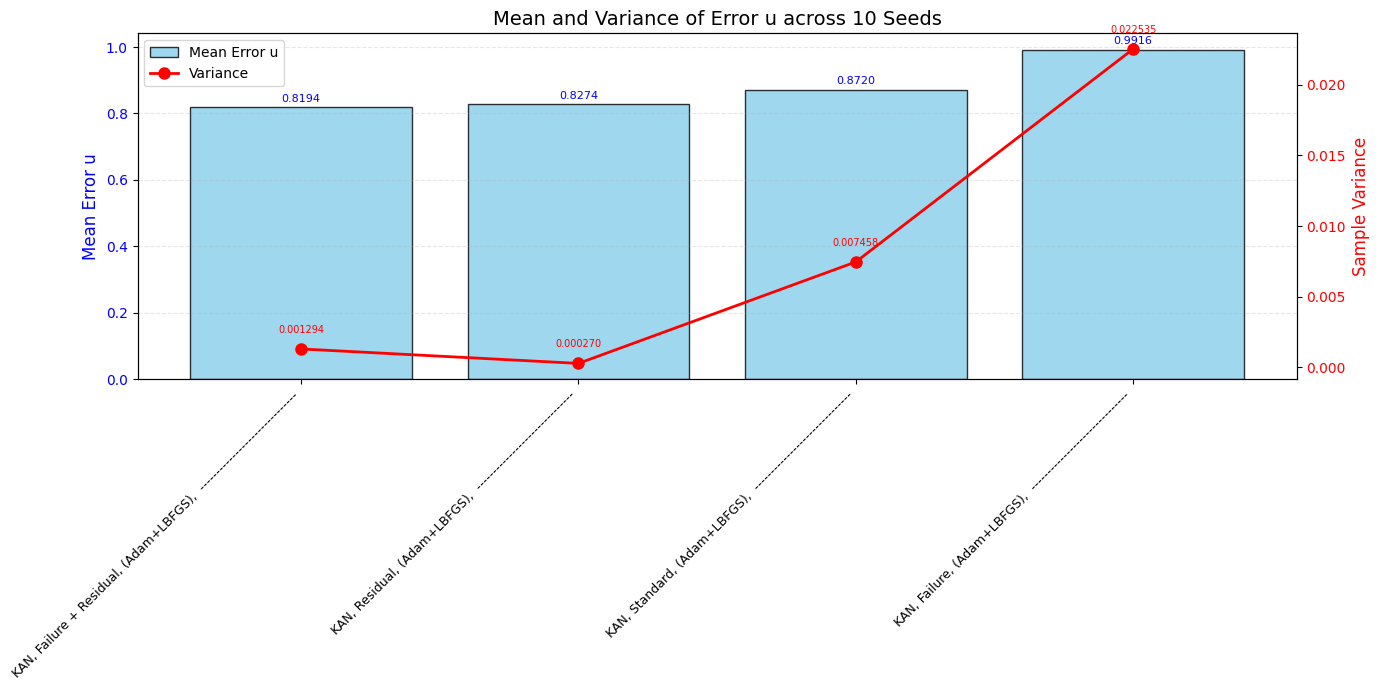

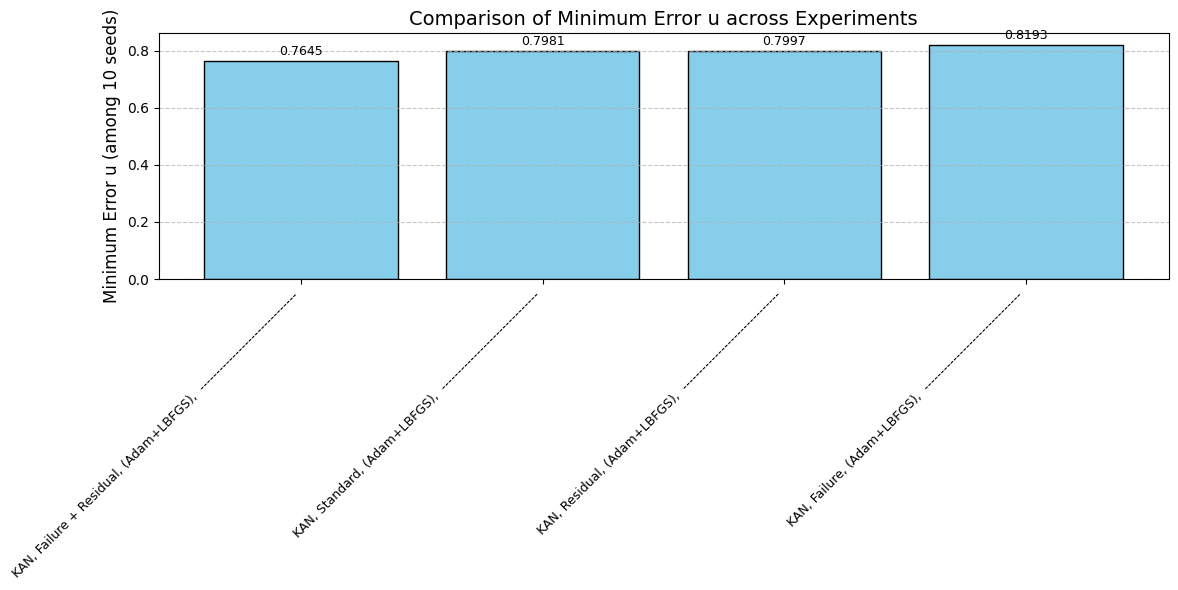

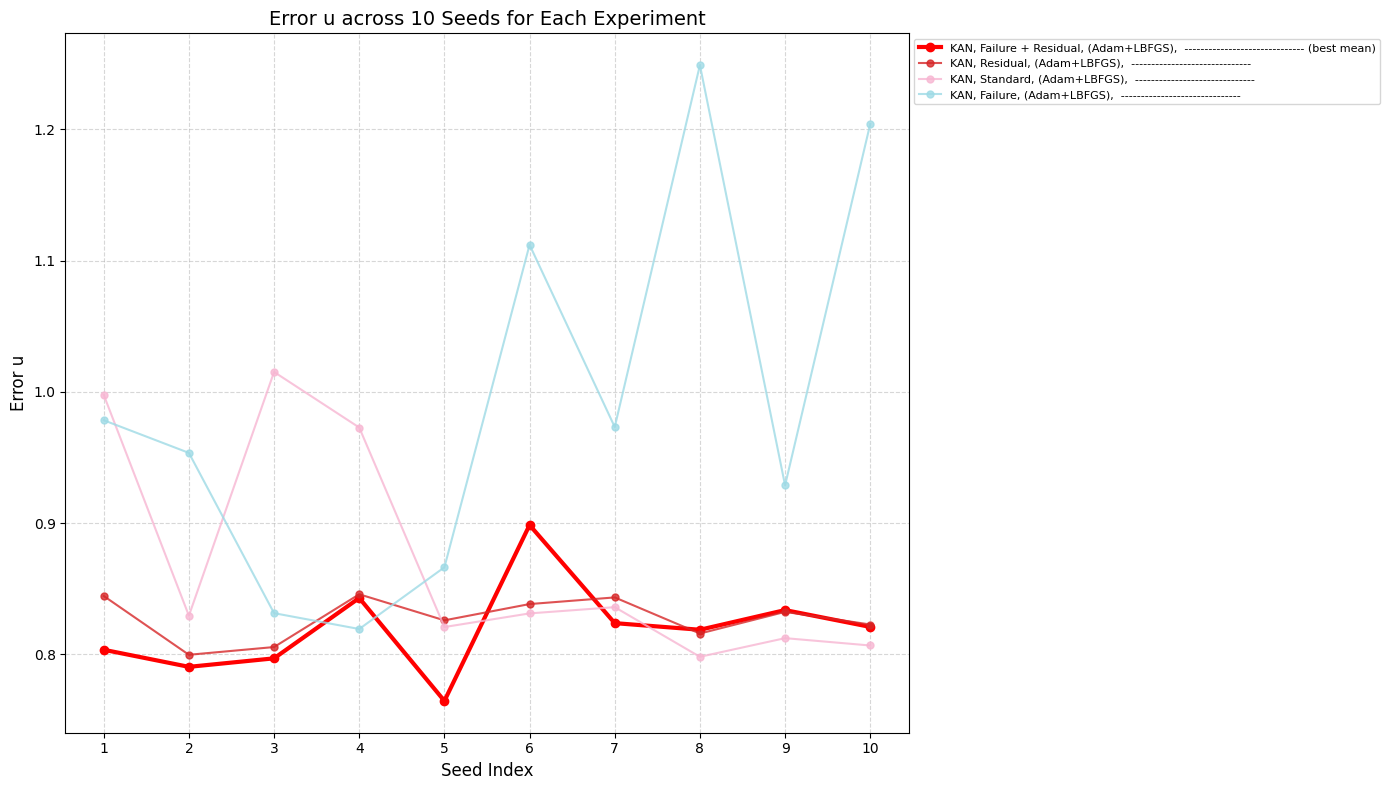

In [4]:

plot_mean_variance_combined(exp_dict)

# 绘制最小值柱状图（显示全部实验）
plot_min_values(exp_dict)

# 绘制折线图
plot_seed_trends(exp_dict)


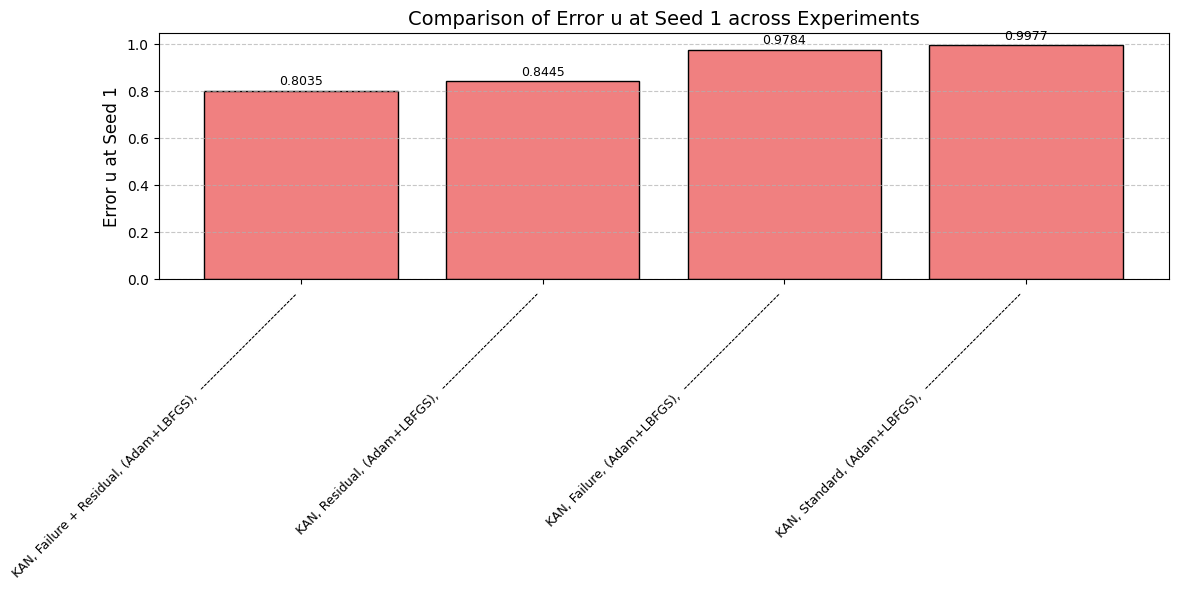

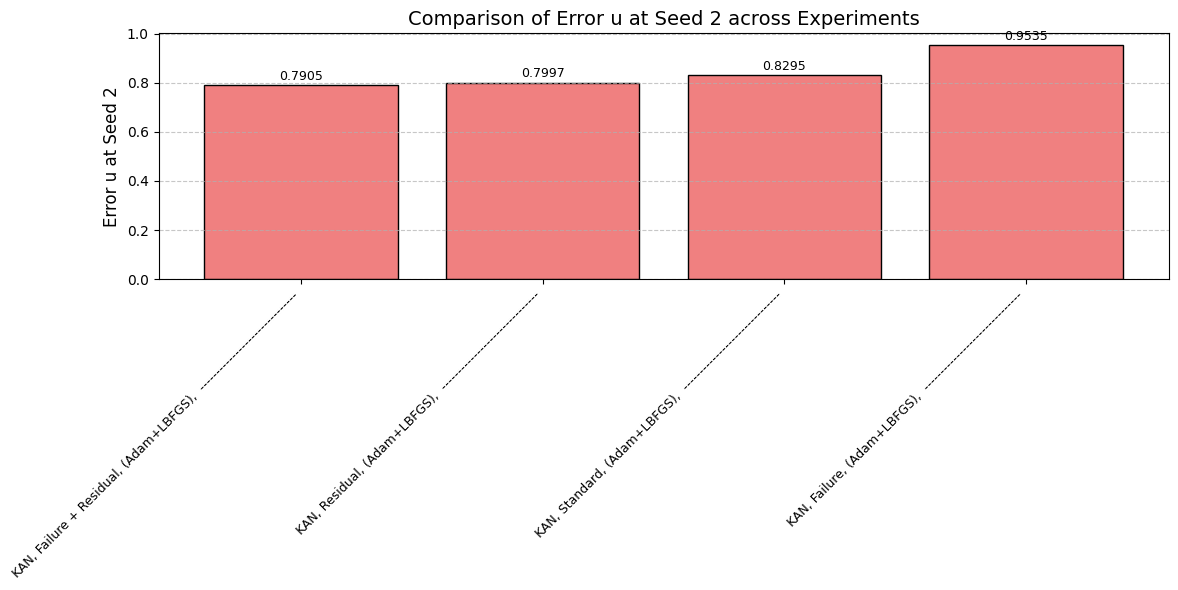

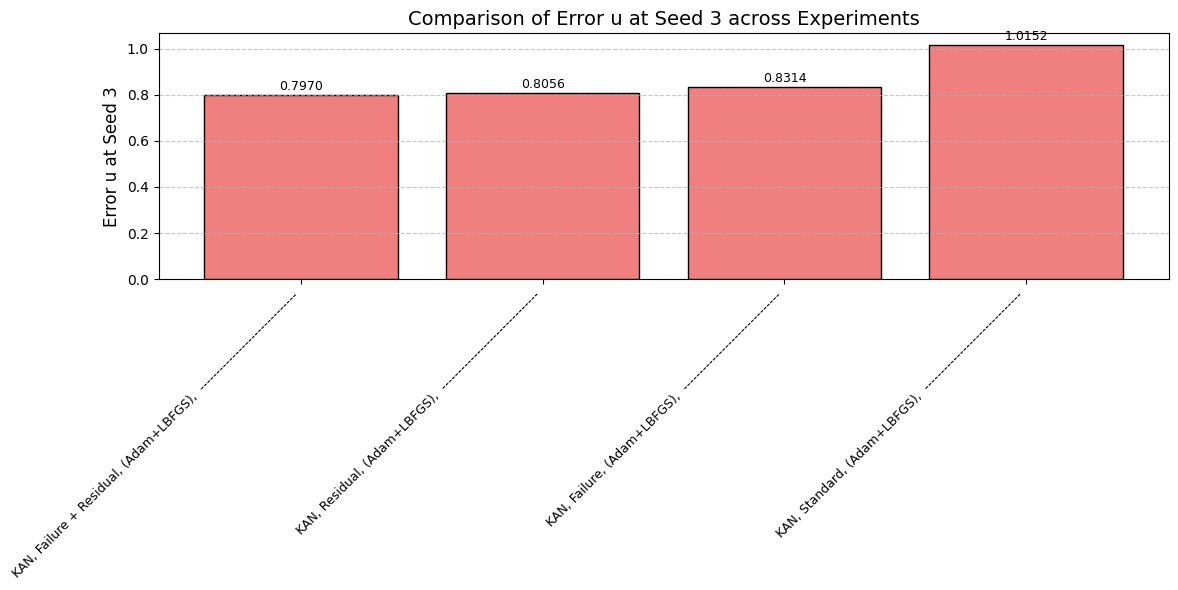

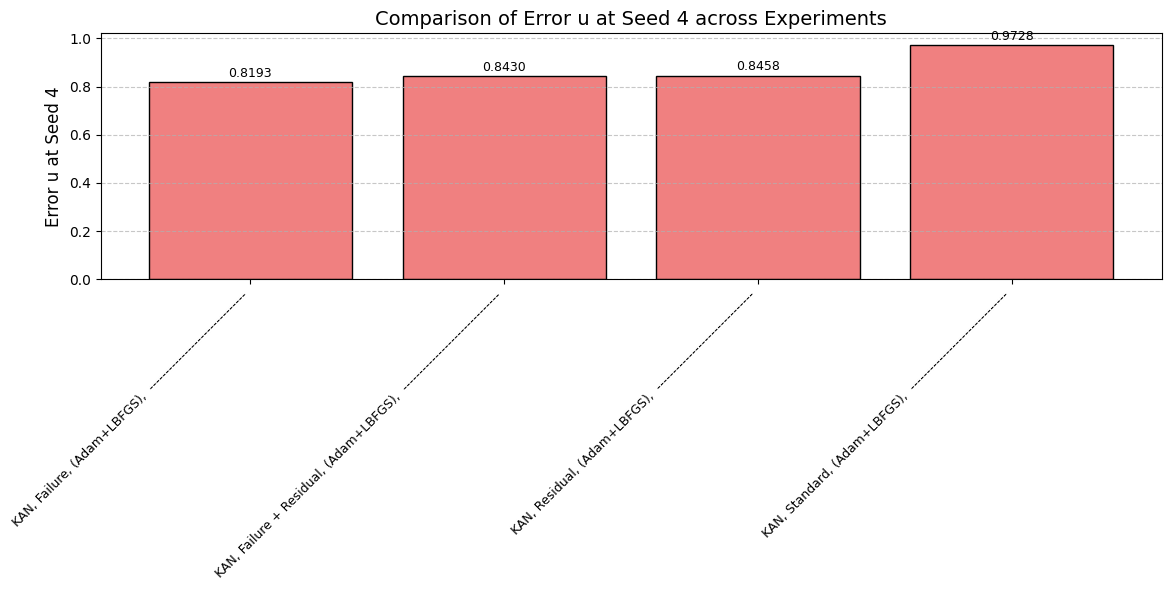

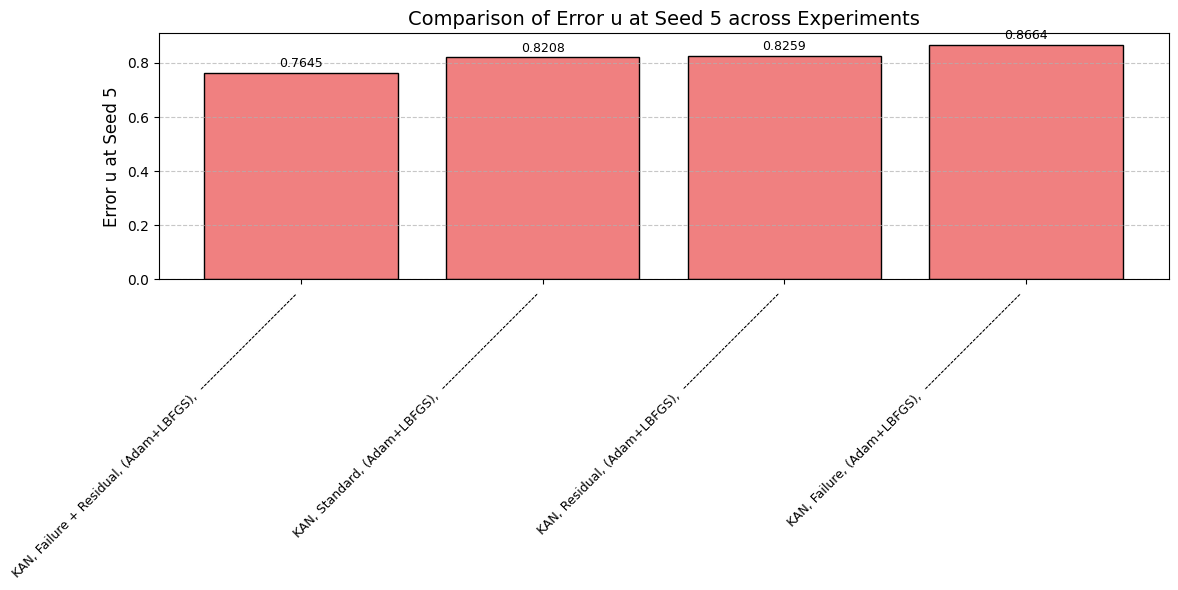

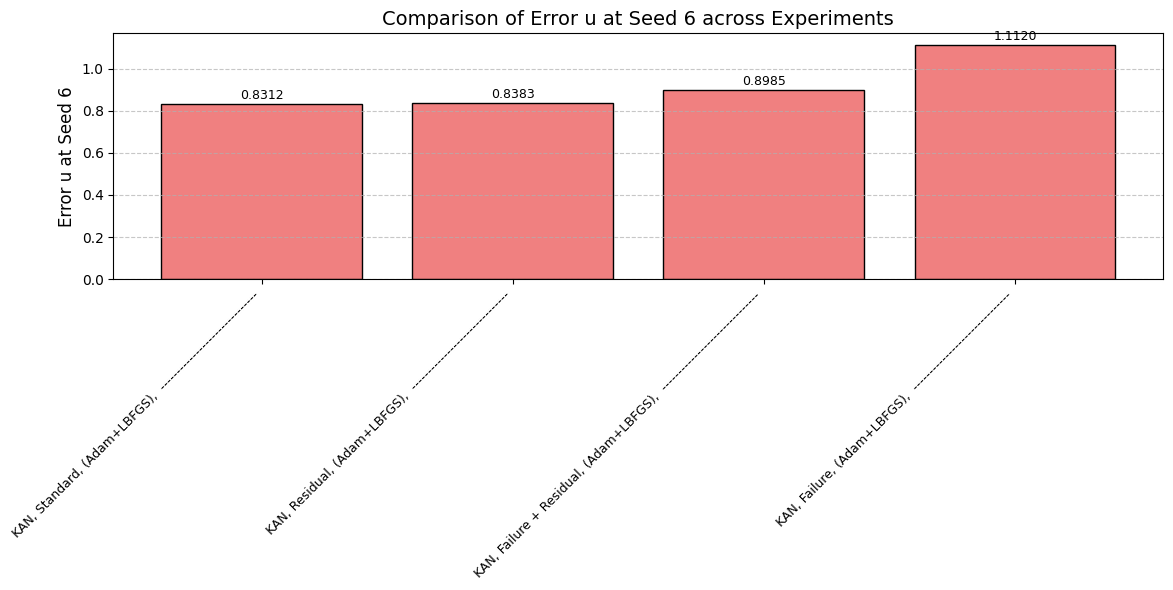

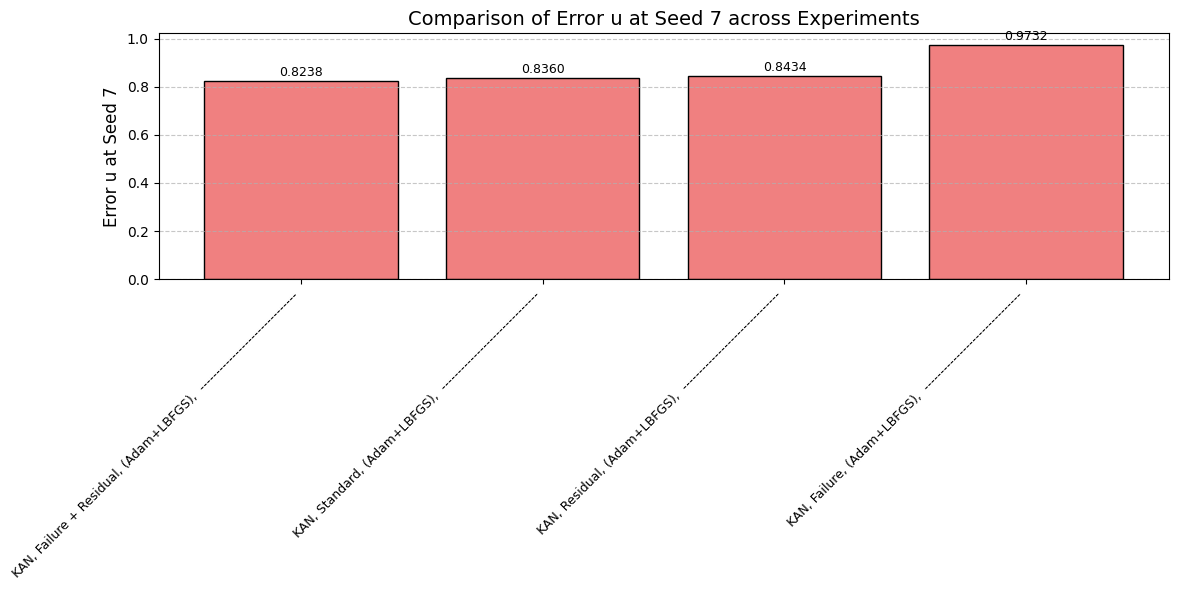

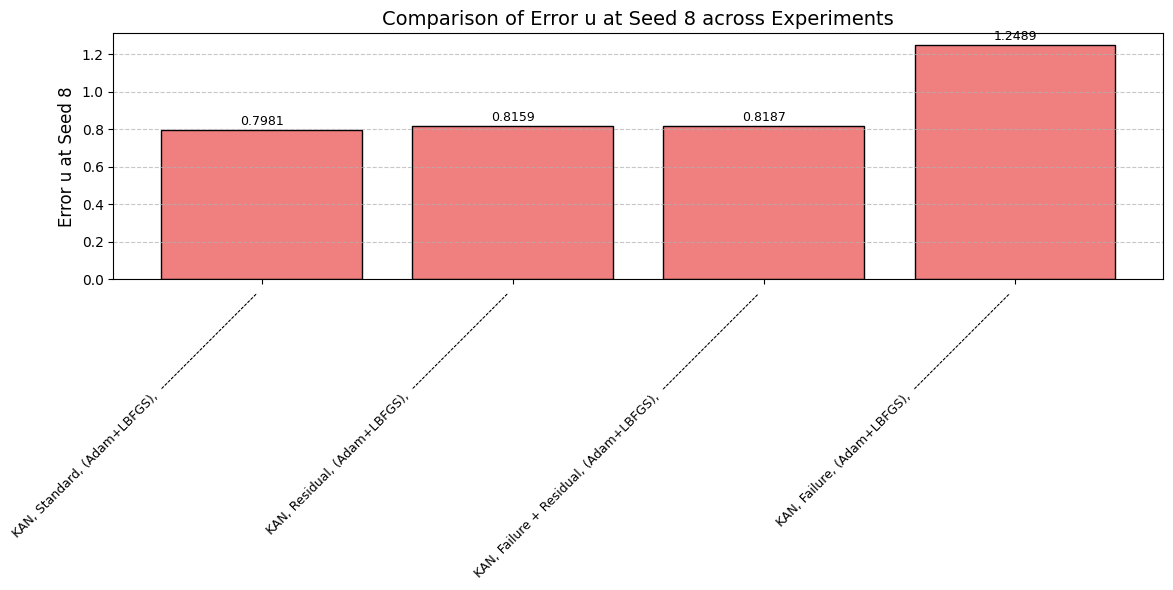

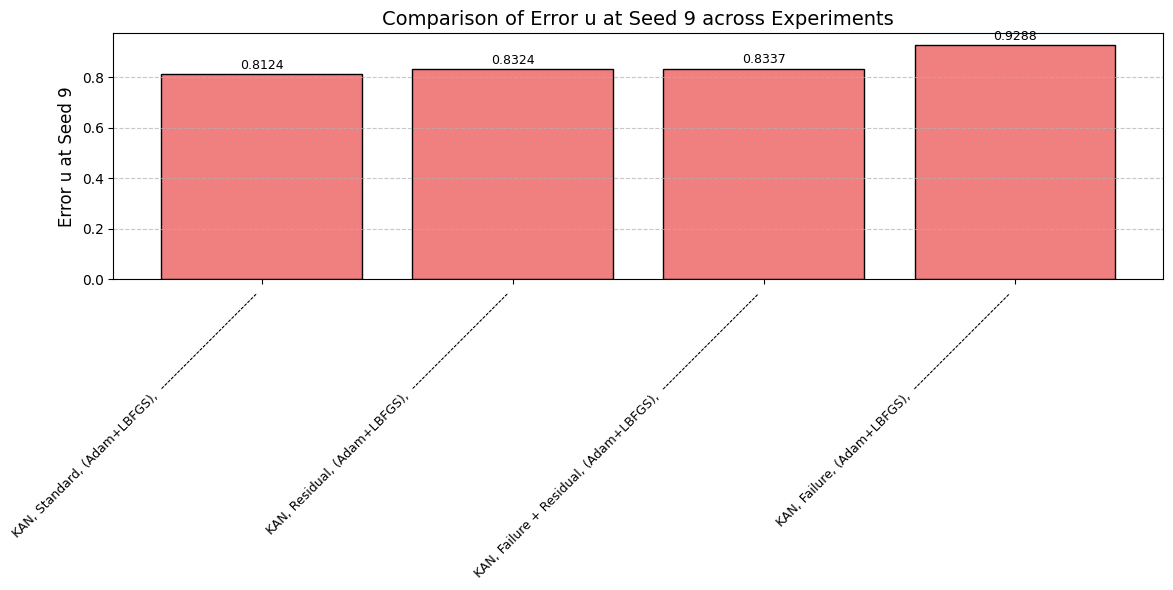

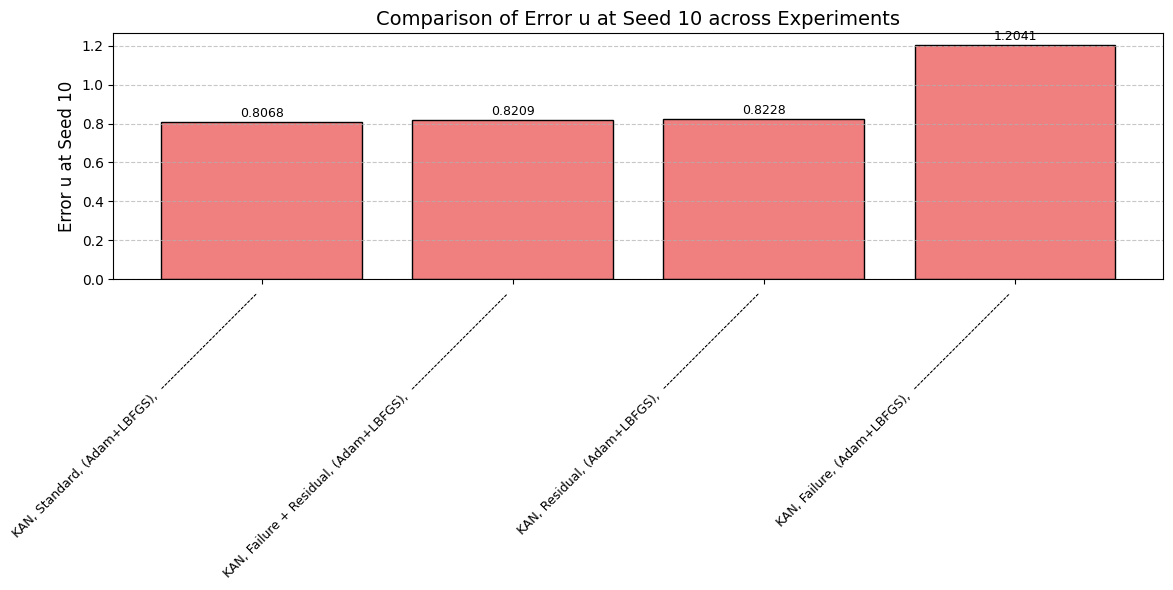

In [5]:
for i in range(10):
    plot_seed_comparison(exp_dict, seed_index = i+1)
# plot_seed_comparison(exp_dict, seed_index=10)